# STAT 4051 Group Project: Sparse PCA with *Breast Cancer Gene Expression Dataset*

In [ ]:
! pip3.12 install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "orvile/gene-expression-profiles-of-breast-cancer"
)
print(path)

Using Colab cache for faster access to the 'gene-expression-profiles-of-breast-cancer' dataset.
/kaggle/input/gene-expression-profiles-of-breast-cancer


In [ ]:
import os
for root, dirs, files in os.walk(path):
    print(root, files)

/kaggle/input/gene-expression-profiles-of-breast-cancer []
/kaggle/input/gene-expression-profiles-of-breast-cancer/GSE2034 []
/kaggle/input/gene-expression-profiles-of-breast-cancer/GSE2034/GSE2034 ['GSE2034-Tumor.txt', 'GSE2034-Normal.txt']
/kaggle/input/gene-expression-profiles-of-breast-cancer/BC-TCGA []
/kaggle/input/gene-expression-profiles-of-breast-cancer/BC-TCGA/BC-TCGA ['BC-TCGA-Normal.txt', 'BC-TCGA-Tumor.txt']
/kaggle/input/gene-expression-profiles-of-breast-cancer/Simulation-Data []
/kaggle/input/gene-expression-profiles-of-breast-cancer/Simulation-Data/Simulation-Data ['Simulation-Data-Tumor.txt', 'README', 'Simulation-Data-Normal.txt']
/kaggle/input/gene-expression-profiles-of-breast-cancer/GSE25066 []
/kaggle/input/gene-expression-profiles-of-breast-cancer/GSE25066/GSE25066 ['GSE25066-Tumor.txt', 'GSE25066-Normal.txt']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, SparsePCA
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

import seaborn as sns

We will compare the PCA and Sparse PCA below:

(590, 17815)
1695
Pre-filter: 17814 genes → 1000 genes
Variance cutoff: 1.0000
Kept genes variance range: [1.0000, 1.0000]


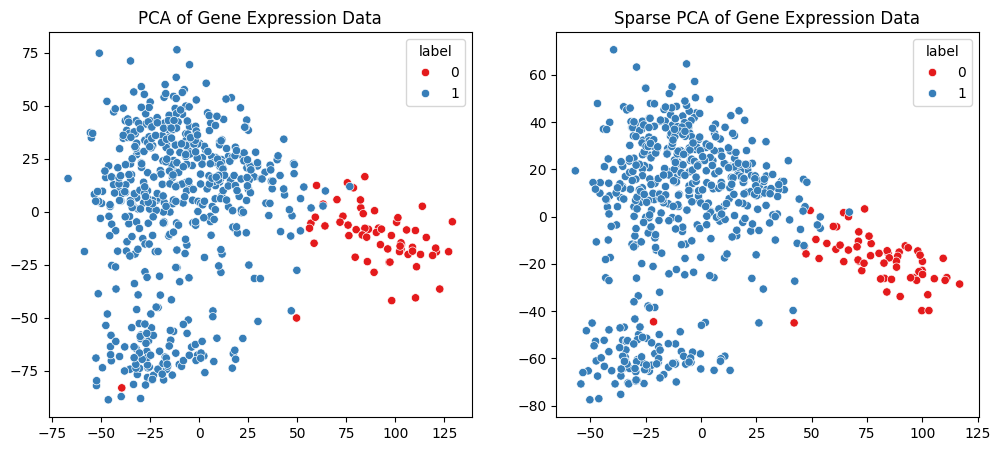

In [ ]:

# load dataset
normal_file = os.path.join(path, "BC-TCGA", "BC-TCGA", "BC-TCGA-Normal.txt")
tumor_file = os.path.join(path, "BC-TCGA", "BC-TCGA", "BC-TCGA-Tumor.txt")
normal = pd.read_csv(normal_file, sep="\t")
tumor = pd.read_csv(tumor_file, sep="\t")

normal = normal.set_index("Hybridization REF")
tumor = tumor.set_index("Hybridization REF")

normal_T = normal.T
tumor_T = tumor.T

normal_T["label"] = 0
tumor_T["label"] = 1

# combine normal and tumor datasets
data = pd.concat([normal_T, tumor_T])
print(data.shape)
# print(data.head())
print(data.isna().sum().sum())
# separate features and labels
X = data.drop("label", axis=1)
y = data["label"]
# impute missing values
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X)
# standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
variances = np.var(X_scaled, axis=0)
TOP_K = 1000

top_indices = np.argsort(variances)[-TOP_K:]
top_indices.sort()

X_filtered = X_scaled[:, top_indices]
filtered_gene_names = X.columns[top_indices]

print(f"Pre-filter: {X_scaled.shape[1]} genes → {X_filtered.shape[1]} genes")
print(f"Variance cutoff: {variances[top_indices[0]]:.4f}")
print(f"Kept genes variance range: [{variances[top_indices[0]]:.4f}, {variances[top_indices[-1]]:.4f}]")
# apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# apply Sparse PCA
sparse_pca = SparsePCA(n_components=2, alpha=5, random_state=42, n_jobs=-1)
X_sparse_pca = sparse_pca.fit_transform(X_scaled)
# visualize PCA results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="Set1")
plt.title("PCA of Gene Expression Data")
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_sparse_pca[:, 0], y=X_sparse_pca[:, 1], hue=y, palette="Set1")
plt.title("Sparse PCA of Gene Expression Data")
plt.show()


In [ ]:
# PCA reconstruction
X_pca_recon = pca.inverse_transform(X_pca)
pca_error = np.mean((X_scaled - X_pca_recon) ** 2)

# Sparse PCA reconstruction
X_spca_recon = sparse_pca.inverse_transform(X_sparse_pca)
spca_error = np.mean((X_scaled - X_spca_recon) ** 2)

print("PCA reconstruction error:", pca_error)
print("Sparse PCA reconstruction error:", spca_error)

nonzero_pca = np.sum(pca.components_ != 0)
total_pca = pca.components_.size
print("PCA non-zero loadings:", nonzero_pca)
print("PCA sparsity ratio:", nonzero_pca / total_pca)

nonzero = np.sum(sparse_pca.components_ != 0)
total = sparse_pca.components_.size

print("Non-zero loadings:", nonzero)
print("Sparsity ratio:", nonzero / total)

PCA reconstruction error: 0.837459830664955
Sparse PCA reconstruction error: 0.8663177694014954
PCA non-zero loadings: 35628
PCA sparsity ratio: 1.0
Non-zero loadings: 16442
Sparsity ratio: 0.4614909621645896


Since the initial results with n_components=2 were not ideal, we increased it to n_components=20 and conducted an alpha sweep to find a better regularization parameter.

In [ ]:
N_COMP = 20
print(f"\nUsing n_components = {N_COMP}")

# PCA baseline
pca_base = PCA(n_components=N_COMP, random_state=42)
X_pca_base = pca_base.fit_transform(X_filtered)
X_pca_recon = pca_base.inverse_transform(X_pca_base)
pca_base_error = np.mean((X_filtered - X_pca_recon) ** 2)

nonzero_pca = np.sum(pca_base.components_ != 0)
total_pca = pca_base.components_.size

print("PCA reconstruction error:", pca_base_error)
print("PCA non-zero loadings:", nonzero_pca)
print("PCA sparsity ratio:", nonzero_pca / total_pca)

alphas = [3.0, 4.0, 5.0, 7.0, 10.0]

import signal

class TimeoutError(Exception):
    pass

def timeout_handler(signum, frame):
    raise TimeoutError("Timed out")

TIMEOUT_MINUTES = 6

results = []
print(f"\nSweeping alpha values (timeout={TIMEOUT_MINUTES}min per alpha)...")

for a in alphas:
    print(f"\n  alpha={a} ...", flush=True)

    signal.signal(signal.SIGALRM, timeout_handler)
    signal.alarm(TIMEOUT_MINUTES * 60)

    try:
        spca = SparsePCA(n_components=N_COMP, alpha=a, random_state=42, max_iter=500, n_jobs=-1)
        X_spca = spca.fit_transform(X_filtered)
        X_recon = spca.inverse_transform(X_spca)

        signal.alarm(0)

        error = np.mean((X_filtered - X_recon) ** 2)
        nonzero = np.sum(spca.components_ != 0)
        total = spca.components_.size
        genes_selected = np.sum(np.any(spca.components_ != 0, axis=0))
        total_genes = spca.components_.shape[1]

        print(f"  Sparse PCA reconstruction error: {error}")
        print(f"  Non-zero loadings: {nonzero}")
        print(f"  Sparsity ratio: {nonzero / total}")

        results.append({
            'alpha': a,
            'recon_error': error,
            'error_increase_pct': (error - pca_base_error) / pca_base_error * 100,
            'nonzero_loadings': nonzero,
            'sparsity_ratio': nonzero / total,
            'genes_selected': genes_selected,
            'gene_select_ratio': genes_selected / total_genes,
        })

    except TimeoutError:
        signal.alarm(0)
        print(f"  KILLED after {TIMEOUT_MINUTES}min, skipping")
    except Exception as e:
        signal.alarm(0)
        print(f"  ERROR: {e}, skipping")

df_results = pd.DataFrame(results)
print("\n=== Full Results Table ===")
print(df_results.to_string(index=False))



Using n_components = 20
PCA reconstruction error: 0.5191758067836266
PCA non-zero loadings: 20000
PCA sparsity ratio: 1.0

Sweeping alpha values (timeout=6min per alpha)...

  alpha=3.0 ...
  Sparse PCA reconstruction error: 0.6224739782522499
  Non-zero loadings: 4392
  Sparsity ratio: 0.2196

  alpha=4.0 ...
  Sparse PCA reconstruction error: 0.6517023685535467
  Non-zero loadings: 3113
  Sparsity ratio: 0.15565

  alpha=5.0 ...
  Sparse PCA reconstruction error: 0.6814286865523018
  Non-zero loadings: 2323
  Sparsity ratio: 0.11615

  alpha=7.0 ...
  Sparse PCA reconstruction error: 0.7253507777372957
  Non-zero loadings: 1410
  Sparsity ratio: 0.0705

  alpha=10.0 ...
  Sparse PCA reconstruction error: 0.8166399138417032
  Non-zero loadings: 617
  Sparsity ratio: 0.03085

=== Full Results Table ===
 alpha  recon_error  error_increase_pct  nonzero_loadings  sparsity_ratio  genes_selected  gene_select_ratio
   3.0     0.622474           19.896569              4392         0.21960   

#visualization

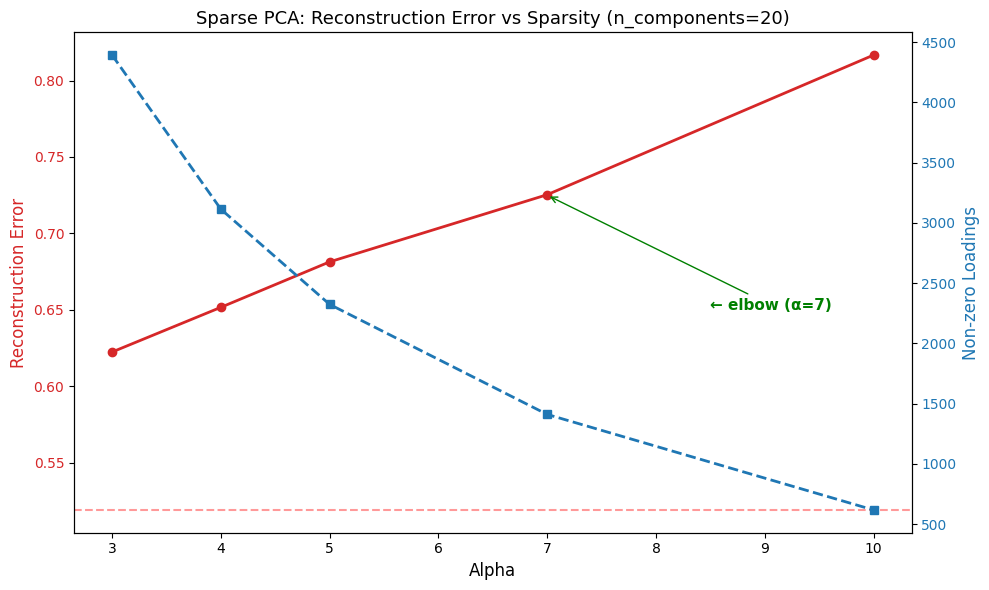

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:red'
ax1.set_xlabel('Alpha', fontsize=12)
ax1.set_ylabel('Reconstruction Error', color=color1, fontsize=12)
ax1.plot(df_results['alpha'], df_results['recon_error'], 'o-', color=color1, linewidth=2, label='Sparse PCA Error')
ax1.axhline(y=pca_base_error, color='red', linestyle='--', alpha=0.4, label='PCA baseline')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Non-zero Loadings', color=color2, fontsize=12)
ax2.plot(df_results['alpha'], df_results['nonzero_loadings'], 's--', color=color2, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# 标注 elbow point
ax1.annotate('← elbow (α=7)', xy=(7, 0.725), xytext=(8.5, 0.65),
             fontsize=11, color='green', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='green'))

plt.title(f'Sparse PCA: Reconstruction Error vs Sparsity (n_components={N_COMP})', fontsize=13)
fig.tight_layout()
plt.show()

Based on the elbow method, we decided to use alpha=7.


In [ ]:
BEST_ALPHA = 7.0

best_idx = next(i for i, r in enumerate(results) if r['alpha'] == BEST_ALPHA)

print(f"Fitting final Sparse PCA with alpha={BEST_ALPHA}...")
spca_final = SparsePCA(n_components=N_COMP, alpha=BEST_ALPHA, random_state=42, max_iter=500, n_jobs=-1)
X_spca_final = spca_final.fit_transform(X_filtered)
X_spca_recon_final = spca_final.inverse_transform(X_spca_final)

spca_final_error = np.mean((X_filtered - X_spca_recon_final) ** 2)
nonzero_final = np.sum(spca_final.components_ != 0)
total_final = spca_final.components_.size

print("\n=== Final Model (α=7) ===")
print("PCA reconstruction error:", pca_base_error)
print("Sparse PCA reconstruction error:", spca_final_error)
print("PCA non-zero loadings:", np.sum(pca_base.components_ != 0))
print("PCA sparsity ratio:", np.sum(pca_base.components_ != 0) / pca_base.components_.size)
print("Non-zero loadings:", nonzero_final)
print("Sparsity ratio:", nonzero_final / total_final)

gene_mask = np.any(spca_final.components_ != 0, axis=0)
selected_genes = filtered_gene_names[gene_mask].tolist()
print(f"\nGenes selected: {len(selected_genes)} / {len(filtered_gene_names)}")
print(f"Gene selection ratio: {len(selected_genes) / len(filtered_gene_names):.4f}")
print(f"\nTop 30 selected genes:\n{selected_genes[:30]}")

gene_df = pd.DataFrame({'gene': selected_genes})
gene_df.to_csv('selected_genes_alpha7.csv', index=False)
print("\nSaved full list to selected_genes_alpha7.csv")



Fitting final Sparse PCA with alpha=7.0...

=== Final Model (α=7) ===
PCA reconstruction error: 0.5191758067836266
Sparse PCA reconstruction error: 0.7253507777372957
PCA non-zero loadings: 20000
PCA sparsity ratio: 1.0
Non-zero loadings: 1410
Sparsity ratio: 0.0705

Genes selected: 810 / 1000
Gene selection ratio: 0.8100

Top 30 selected genes:
['ERCC5', 'GPR98', 'CADM4', 'HNRPD', 'CRNKL1', 'CHD9', 'LOC152573', 'GRB2', 'RP5-1077B9.4', 'KIAA0100', 'CRELD2', 'EMX2', 'ASS1', 'LOC729603', 'TFR2', 'SNAPC1', 'CHST6', 'ZNF687', 'EIF3EIP', 'HABP4', 'TMEM125', 'FUT4', 'CHMP7', 'RPL4', 'MIA2', 'KLHL6', 'C9orf30', 'SGSM3', 'BHLHB3', 'FAM73B']

Saved full list to selected_genes_alpha7.csv


# PCA vs Sparse PCA Comparison Visualization

/tmp/ipykernel_44199/2045984114.py:11: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  axes[0].legend(*scatter1.legend_elements(), title='Label', labels=['Normal', 'Tumor'])
/tmp/ipykernel_44199/2045984114.py:18: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  axes[1].legend(*scatter2.legend_elements(), title='Label', labels=['Normal', 'Tumor'])


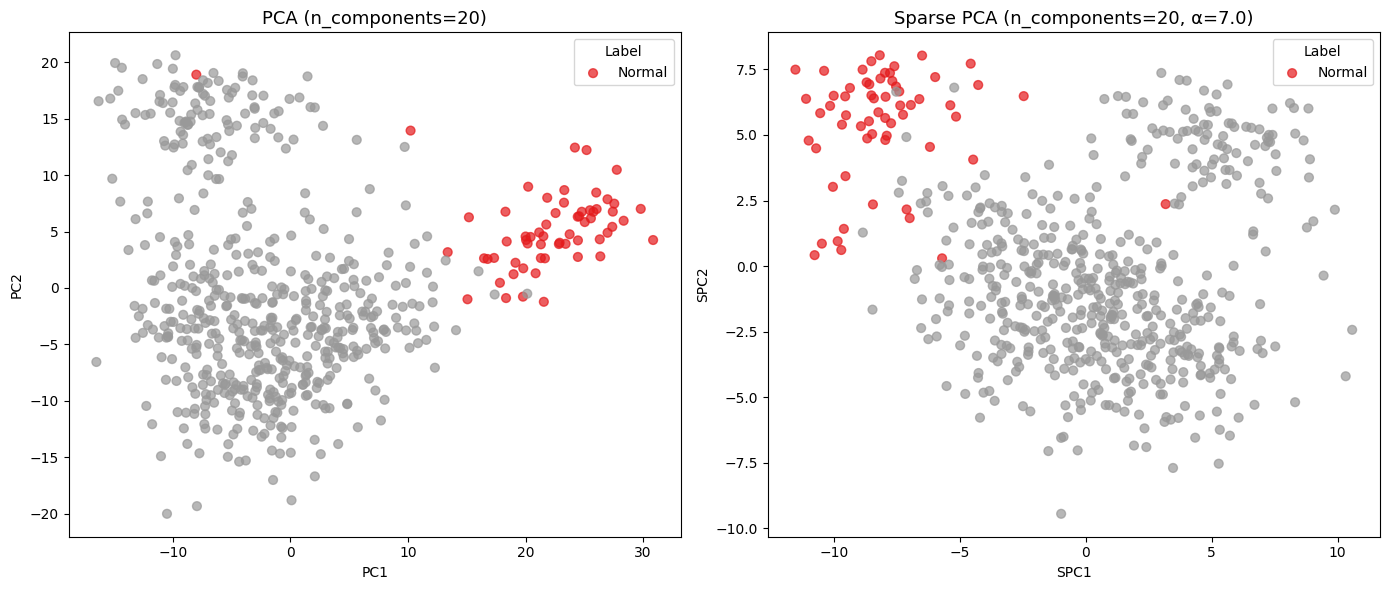

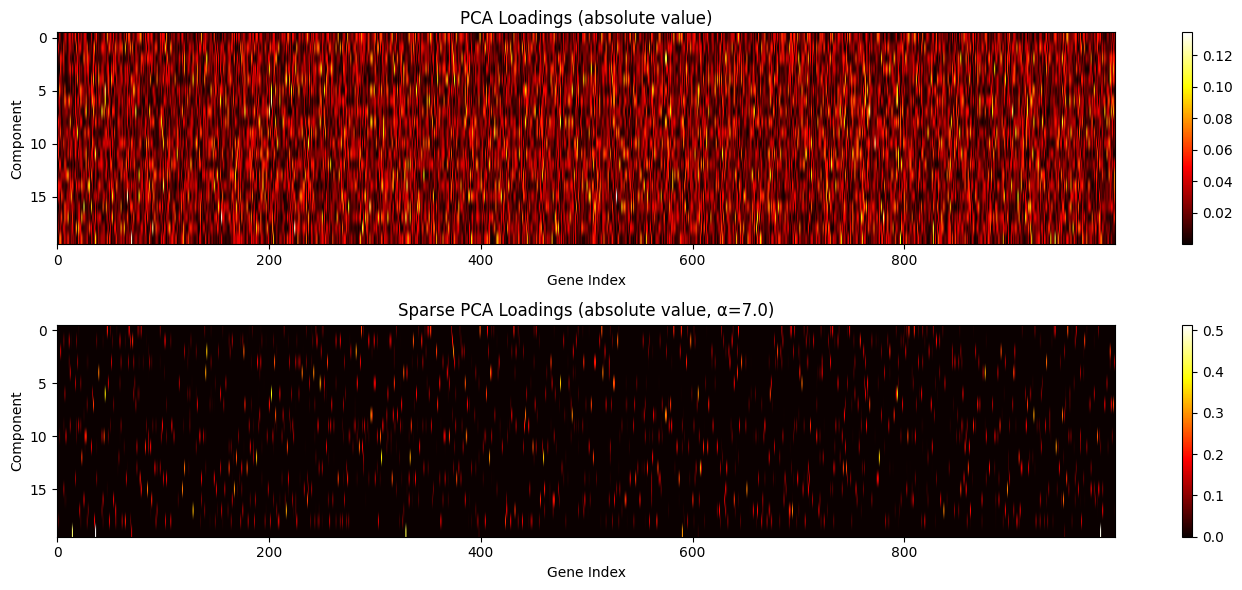


Done. Key takeaway:
  Standard PCA uses all 1000 genes with 20000 non-zero loadings.
  Sparse PCA (α=7.0) achieves 7.0% sparsity,
  selecting 810 genes while increasing reconstruction error by 39.7%.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(X_pca_base[:, 0], X_pca_base[:, 1],
                           c=y, cmap='Set1', alpha=0.7, s=40)
axes[0].set_title(f'PCA (n_components={N_COMP})', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(*scatter1.legend_elements(), title='Label', labels=['Normal', 'Tumor'])

scatter2 = axes[1].scatter(X_spca_final[:, 0], X_spca_final[:, 1],
                           c=y, cmap='Set1', alpha=0.7, s=40)
axes[1].set_title(f'Sparse PCA (n_components={N_COMP}, α={BEST_ALPHA})', fontsize=13)
axes[1].set_xlabel('SPC1')
axes[1].set_ylabel('SPC2')
axes[1].legend(*scatter2.legend_elements(), title='Label', labels=['Normal', 'Tumor'])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# PCA loadings
im1 = axes[0].imshow(np.abs(pca_base.components_), aspect='auto', cmap='hot')
axes[0].set_title('PCA Loadings (absolute value)')
axes[0].set_ylabel('Component')
axes[0].set_xlabel('Gene Index')
plt.colorbar(im1, ax=axes[0])

# Sparse PCA loadings
im2 = axes[1].imshow(np.abs(spca_final.components_), aspect='auto', cmap='hot')
axes[1].set_title(f'Sparse PCA Loadings (absolute value, α={BEST_ALPHA})')
axes[1].set_ylabel('Component')
axes[1].set_xlabel('Gene Index')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("\nDone. Key takeaway:")
print(f"  Standard PCA uses all {len(filtered_gene_names)} genes with {np.sum(pca_base.components_ != 0)} non-zero loadings.")
print(f"  Sparse PCA (α={BEST_ALPHA}) achieves {nonzero_final / total_final:.1%} sparsity,")
print(f"  selecting {len(selected_genes)} genes while increasing reconstruction error by {(spca_final_error - pca_base_error) / pca_base_error * 100:.1f}%.")
